<a href="https://colab.research.google.com/github/Manoj-Kumar-Ejjada-AI/MathforDS/blob/math_manoj/Linear%20Equations/7_linearTransformations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2

<a name='1'></a>
## 1 - Transformations

A **transformation** is a function from one vector space to another that respects the underlying (linear) structure of each vector space. Referring to a specific transformation, you can use a symbol, such as $T$. Specifying the spaces containing the input and output vectors, e.g. $\mathbb{R}^2$ and $\mathbb{R}^3$, you can write $T: \mathbb{R}^2 \rightarrow \mathbb{R}^3$. Transforming vector $v \in \mathbb{R}^2$ into the vector $w\in\mathbb{R}^3$ by the transformation $T$, you can use the notation $T(v)=w$ and read it as "*T of v equals to w*" or "*vector w is an **image** of vector v with the transformation T*".

The following Python function corresponds to the transformation $T: \mathbb{R}^2 \rightarrow \mathbb{R}^3$ with the following symbolic formula:

$$T\begin{pmatrix}
          \begin{bmatrix}
           v_1 \\           
           v_2
          \end{bmatrix}\end{pmatrix}=
          \begin{bmatrix}
           3v_1 \\
           0 \\
           -2v_2
          \end{bmatrix}
          \tag{1}
          $$

In [2]:
def T(v):
    w = np.zeros((3,1))
    w[0,0] = 3*v[0,0]
    w[2,0] = -2*v[1,0]

    return w

v = np.array([[3], [5]])
w = T(v)

print("Original vector:\n", v, "\n\n Result of the transformation:\n", w)

Original vector:
 [[3]
 [5]] 

 Result of the transformation:
 [[  9.]
 [  0.]
 [-10.]]


<a name='2'></a>
## 2 - Linear Transformations

A transformation $T$ is said to be **linear** if the following two properties are true for any scalar $k$, and any input vectors $u$ and $v$:

1. $T(kv)=kT(v)$,
2. $T(u+v)=T(u)+T(v)$.

In the example above $T$ is a linear transformation:

$$T (kv) =
          T \begin{pmatrix}\begin{bmatrix}
          kv_1 \\
          kv_2
          \end{bmatrix}\end{pmatrix} =
          \begin{bmatrix}
           3kv_1 \\
           0 \\
           -2kv_2
          \end{bmatrix} =
          k\begin{bmatrix}
           3v_1 \\
           0 \\
           -2v_2
          \end{bmatrix} =
          kT(v),\tag{2}$$
          
$$T (u+v) =
          T \begin{pmatrix}\begin{bmatrix}
          u_1 + v_1 \\
          u_2 + v_2
          \end{bmatrix}\end{pmatrix} =
          \begin{bmatrix}
           3(u_1+v_1) \\
           0 \\
           -2(u_2+v_2)
          \end{bmatrix} =
          \begin{bmatrix}
           3u_1 \\
           0 \\
           -2u_2
          \end{bmatrix} +
          \begin{bmatrix}
           3v_1 \\
           0 \\
           -2v_2
          \end{bmatrix} =
          T(u)+T(v).\tag{3}$$

You can change the values of $k$ or vectors $u$ and $v$ in the cell below, to check that this is true for some specific values.

In [5]:
u = np.array([[1], [-2]])
v = np.array([[2], [4]])

k = 7

print("T(k*v):\n", T(k*v), "\n k*T(v):\n", k*T(v), "\n\n")
print("T(u+v):\n", T(u+v), "\n T(u)+T(v):\n", T(u)+T(v))

T(k*v):
 [[ 42.]
 [  0.]
 [-56.]] 
 k*T(v):
 [[ 42.]
 [  0.]
 [-56.]] 


T(u+v):
 [[ 9.]
 [ 0.]
 [-4.]] 
 T(u)+T(v):
 [[ 9.]
 [ 0.]
 [-4.]]


Some examples of linear transformations are rotations, reflections, scaling (dilations), etc.

<a name='3'></a>
## 3 - Transformations Defined as a Matrix Multiplication

Let $L: \mathbb{R}^m \rightarrow \mathbb{R}^n$ be defined by a matrix $A$, where $L(v)=Av$, multiplication of the matrix $A$ ($n\times m$) and vector $v$ ($m\times 1$) resulting in the vector $w$ ($n\times 1$).

Now try to guess, what should be the elements of matrix $A$, corresponding to the transformation $L: \mathbb{R}^2 \rightarrow \mathbb{R}^3$:

$$L\begin{pmatrix}
          \begin{bmatrix}
           v_1 \\           
           v_2
          \end{bmatrix}\end{pmatrix}=
          \begin{bmatrix}
           3v_1 \\
           0 \\
           -2v_2
          \end{bmatrix}=
          \begin{bmatrix}
           ? & ? \\
           ? & ? \\
           ? & ?
          \end{bmatrix}
          \begin{bmatrix}
           v_1 \\
           v_2
          \end{bmatrix}
          \tag{4}
          $$

To do that, write the transformation $L$ as $Av$ and then perform matrix multiplication:
    $$L\begin{pmatrix}
          \begin{bmatrix}
           v_1 \\           
           v_2
          \end{bmatrix}\end{pmatrix}=
          A\begin{bmatrix}
           v_1 \\           
           v_2
          \end{bmatrix}=
          \begin{bmatrix}
           a_{1,1} & a_{1,2} \\
           a_{2,1} & a_{2,2} \\
           a_{3,1} & a_{3,2}
          \end{bmatrix}
          \begin{bmatrix}
           v_1 \\           
           v_2
          \end{bmatrix}=
          \begin{bmatrix}
           a_{1,1}v_1+a_{1,2}v_2 \\
           a_{2,1}v_1+a_{2,2}v_2 \\
           a_{3,1}v_1+a_{3,2}v_2 \\
          \end{bmatrix}=
          \begin{bmatrix}
           3v_1 \\
           0 \\
           -2v_2
          \end{bmatrix}\tag{5}
          $$
          
Can you see now what should be the values of the elements $a_{i,j}$ of matrix $A$ to make the equalities $(5)$ correct? Find out the answer in the following code cell:

In [6]:
def L(v):
  A = np.array([[3,0],[0,0],[0,-1]])
  w = A@v
  return w

v = np.array([[3], [5]])
w = L(v)

print("Original vector:\n", v, "\n\n Result of the transformation:\n", w)

Original vector:
 [[3]
 [5]] 

 Result of the transformation:
 [[ 9]
 [ 0]
 [-5]]


In [7]:
x = np.array([[4],[9]])
y = L(x)
print("Original vector:\n", x, "\n\n Result of the transformation:\n", y)

Original vector:
 [[4]
 [9]] 

 Result of the transformation:
 [[12]
 [ 0]
 [-9]]


Every linear transformation can be carried out by matrix multiplication. And vice versa, carrying out matrix multiplication, it is natural to consider the linear transformation that it represents. **It means you can associate the matrix with the linear transformation in some way**. This is a key connection between linear transformations and matrix algebra.

<a name='4'></a>
## 4 - Standard Transformations in a Plane

As discussed above in section [3](#3), a linear transformation $L: \mathbb{R}^2 \rightarrow \mathbb{R}^2$ can be represented as a multiplication of a $2 \times 2$ matrix and a coordinate vector $v\in\mathbb{R}^2.$ Note that so far you have been using some random vector $v\in\mathbb{R}^2.$ (e.g. $v=\begin{bmatrix}3 \\ 5\end{bmatrix}$). To have a better intuition of what the transformation is really doing in the $\mathbb{R}^2$ space, it is wise to choose vector $v$ in a less random way.

A good choice would be vectors of a standard basis $e_1=\begin{bmatrix}1 \\ 0\end{bmatrix}$ and $e_2=\begin{bmatrix}0 \\ 1\end{bmatrix}$. Let's apply linear transformation $L$ to each of the vectors $e_1$ and $e_2$: $L(e_1)=Ae_1$ and $L(e_2)=Ae_2$. If you put vectors $\{e_1, e_2\}$ into columns of a matrix and perform matrix multiplication

$$A\begin{bmatrix}e_1 & e_2\end{bmatrix}=\begin{bmatrix}Ae_1 & Ae_2\end{bmatrix}=\begin{bmatrix}L(e_1) & L(e_2)\end{bmatrix},\tag{3}$$

you can note that $\begin{bmatrix}e_1 & e_2\end{bmatrix}=\begin{bmatrix}1 & 0 \\ 0 & 1\end{bmatrix}$ (identity matrix). Thus, $A\begin{bmatrix}e_1 & e_2\end{bmatrix} = AI=A$, and

$$A=\begin{bmatrix}L(e_1) & L(e_2)\end{bmatrix}.\tag{4}$$

This is a matrix with the columns that are the images of the vectors of the standard basis.

This choice of vectors \{$e_1, e_2$\} provides opportinuty for the visual representation of the linear transformation $L$ (you will see the examples below).

Horizontal scaling (factor $2$ in this example) can be defined considering transformation of a vector $e_1=\begin{bmatrix}1 \\ 0\end{bmatrix}$ into a vector $\begin{bmatrix}2 \\ 0\end{bmatrix}$ and leaving vector $e_2=\begin{bmatrix}0 \\ 1\end{bmatrix}$ without any changes. The following function `T_hscaling()` corresponds to the horizontal scaling (factor $2$) of a vector. The second function `transform_vectors()` applies defined transformation to a set of vectors (here two vectors).

In [8]:
def T_hscaling(v):
    A = np.array([[2,0], [0,1]])
    w = A @ v

    return w


def transform_vectors(T, v1, v2):
    V = np.hstack((v1, v2))
    W = T(V)

    return W

e1 = np.array([[1], [0]])
e2 = np.array([[0], [1]])

transformation_result_hscaling = transform_vectors(T_hscaling, e1, e2)

print("Original vectors:\n e1= \n", e1, "\n e2=\n", e2,
      "\n\n Result of the transformation (matrix form):\n", transformation_result_hscaling)

Original vectors:
 e1= 
 [[1]
 [0]] 
 e2=
 [[0]
 [1]] 

 Result of the transformation (matrix form):
 [[2 0]
 [0 1]]


You can get a visual understanding of the transformation, producing a plot which displays input vectors, and their transformations. Do not worry if the code in the following cell will not be clear - at this stage this is not important code to understand.

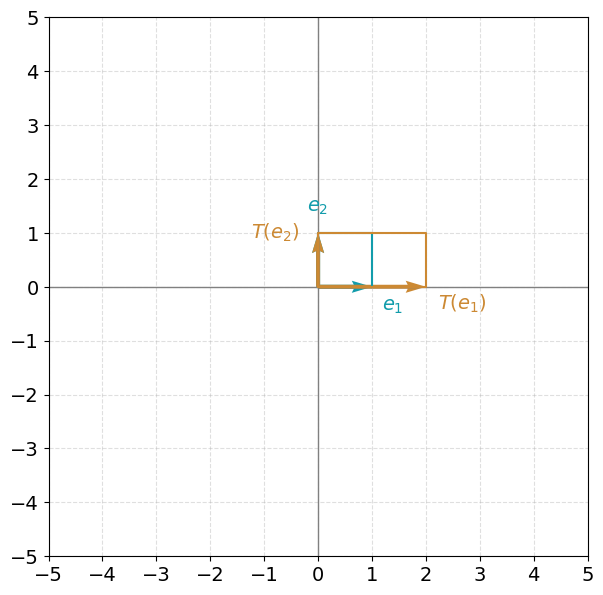

In [9]:
import matplotlib.pyplot as plt

def plot_transformation(T, e1, e2):
    color_original = "#129cab"
    color_transformed = "#cc8933"

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticks(np.arange(-5, 6))
    ax.set_yticks(np.arange(-5, 6))
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.axhline(0, color='grey', lw=1)
    ax.axvline(0, color='grey', lw=1)

    # Original basis vectors
    ax.quiver([0, 0], [0, 0], [e1[0], e2[0]], [e1[1], e2[1]],
              color=color_original, angles='xy', scale_units='xy', scale=1)
    ax.plot([0, e2[0], e1[0]+e2[0], e1[0], 0],
            [0, e2[1], e1[1]+e2[1], e1[1], 0],
            color=color_original)
    # e1 and e2 labels (with custom non-overlapping offset)
    ax.text(e1[0]+0.18, e1[1]-0.18, '$e_1$', fontsize=14, color=color_original, ha='left', va='top')
    ax.text(e2[0], e2[1]+0.3, '$e_2$', fontsize=14, color=color_original, ha='center', va='bottom')

    # Transformed basis
    e1_t = T(e1)
    e2_t = T(e2)
    ax.quiver([0, 0], [0, 0], [e1_t[0], e2_t[0]], [e1_t[1], e2_t[1]],
              color=color_transformed, angles='xy', scale_units='xy', scale=1)
    ax.plot([0, e2_t[0], e1_t[0]+e2_t[0], e1_t[0], 0],
            [0, e2_t[1], e1_t[1]+e2_t[1], e1_t[1], 0],
            color=color_transformed)
    # Transformed labels, **different offset to avoid overlap!**
    ax.text(e1_t[0]+0.22, e1_t[1]-0.10, '$T(e_1)$', fontsize=14, color=color_transformed, ha='left', va='top')
    ax.text(e2_t[0]-0.35, e2_t[1], '$T(e_2)$', fontsize=14, color=color_transformed, ha='right', va='center')

    ax.set_aspect("equal")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

def T_hscaling(v):  # scales x by 2, leaves y as is
    return np.array([2*v[0], v[1]])

e1 = np.array([1,0])
e2 = np.array([0,1])

plot_transformation(T_hscaling, e1, e2)

<a name='4.2'></a>
### 4.2 - Example 2: Reflection about y-axis (the vertical axis)

Function `T_reflection_yaxis()` defined below corresponds to the reflection about y-axis:

In [10]:
def T_reflection_yaxis(v):

    A = np.array([[-1,0], [0,1]])

    return A @ v

e1 = np.array([1, 0])
e2 = np.array([0, 1])

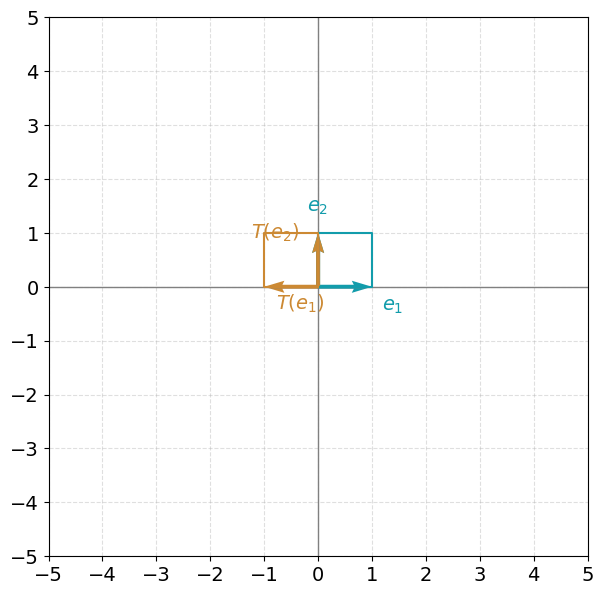

In [11]:
plot_transformation(T_reflection_yaxis, e1, e2)